# spiral arms (Cox & Gomez 2002) on top of a MW-like disk

quick look at the `CoxGomezSpiralPotential` I added -- density of a rotating
2-armed spiral superposed on a Miyamoto-Nagai disk, and the acceleration
field of the spiral perturbation on its own.

In [1]:
import streamsculptor as ssc
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as const

jax.config.update("jax_enable_x64", True)

### disk + spiral setup

disk is just a plain MN disk with roughly MW thin-disk params. for the spiral
I'm using the numbers from the Cox & Gomez "concentrated arms" example (their
Fig 4/5), N=2, pitch angle 15 deg, converted to code units (kpc, Myr, Msun,
rad).

In [4]:
disk = ssc.potential.MiyamotoNagaiDisk(m=6.8e10, a=3.0, b=0.28)

# rho_o = m_avg * n_o, n_o = 1 atom/cm^3, m_avg = (14/11) m_H  (Cox & Gomez sec 4)
n_o = 1.0 / u.cm**3 # n_0 number density of H atoms
m_avg = (14.0 / 11.0) * const.m_p
rho_o = (m_avg * n_o).to(u.Msun / u.kpc**3).value
rho_o

np.float64(31454215.707326062)

In [24]:
# trailing pattern, Omega < 0 for prograde/trailing convention used in DehnenBarPotential
Omega = (-10.0 * u.km / u.s / u.kpc).to(1.0 / u.Myr, equivalencies=u.dimensionless_angles()).value
Omega

spiral = ssc.potential.CoxGomezSpiralPotential(
    N=3,
    alpha=np.deg2rad(15.0),
    r_s=7.0,
    r_o=8.0,
    rho_o=rho_o,
    H=0.18,
    phi_o=0.0,
    Omega=Omega,
)

pot = ssc.potential.Potential_Combine([disk, spiral])

In [25]:
help(ssc.potential.CoxGomezSpiralPotential)

Help on class CoxGomezSpiralPotential in module streamsculptor.potential:

class CoxGomezSpiralPotential(streamsculptor.main.Potential)
 |  CoxGomezSpiralPotential(
 |      N,
 |      alpha,
 |      r_s,
 |      r_o,
 |      rho_o,
 |      H,
 |      phi_o=0.0,
 |      Omega=0.0,
 |      Cn=(0.8488263631567752, 0.5, 0.16976527263135505),
 |      units=GalacticUnitSystem(G=4.498502151469554e-12)
 |  )
 |
 |  Logarithmic spiral-arm potential of Cox & Gomez (2002), ApJS 142, 261
 |  (astro-ph/0207635), Eq. 8.
 |
 |  Parameters
 |  ----------
 |  N : number of spiral arms
 |  alpha : pitch angle [radians]
 |  r_s : radial scale length of the arm density dropoff
 |  r_o : fiducial radius
 |  rho_o : midplane arm density at r_o
 |  H : scale height of the arm density perturbation
 |  phi_o : phase angle of the spiral at r_o (phi_p(r_o) in the paper)
 |  Omega : pattern speed; the spiral phase is advanced by Omega * t
 |  Cn : amplitudes of the harmonic terms n=1,2,... in the sum of Eq. 4/8.


### midplane density, a few snapshots in time

pattern rotates at Omega for ~200 Myr, evaluate disk+spiral density on a grid
in the midplane at each snapshot.

In [26]:
x = jnp.linspace(-15.0, 15.0, 200)
y = jnp.linspace(-15.0, 15.0, 200)
X, Y = jnp.meshgrid(x, y)
xyz_grid = jnp.stack([X.ravel(), Y.ravel(), jnp.zeros(X.size)], axis=-1)

density_fn = jax.jit(jax.vmap(pot.density, in_axes=(0, None)))

times = jnp.array([0.0, 70.0, 140.0, 200.0])

dens_snapshots = [np.array(density_fn(xyz_grid, float(t))).reshape(X.shape) for t in times]

/opt/anaconda3/envs/streamsculptor_env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


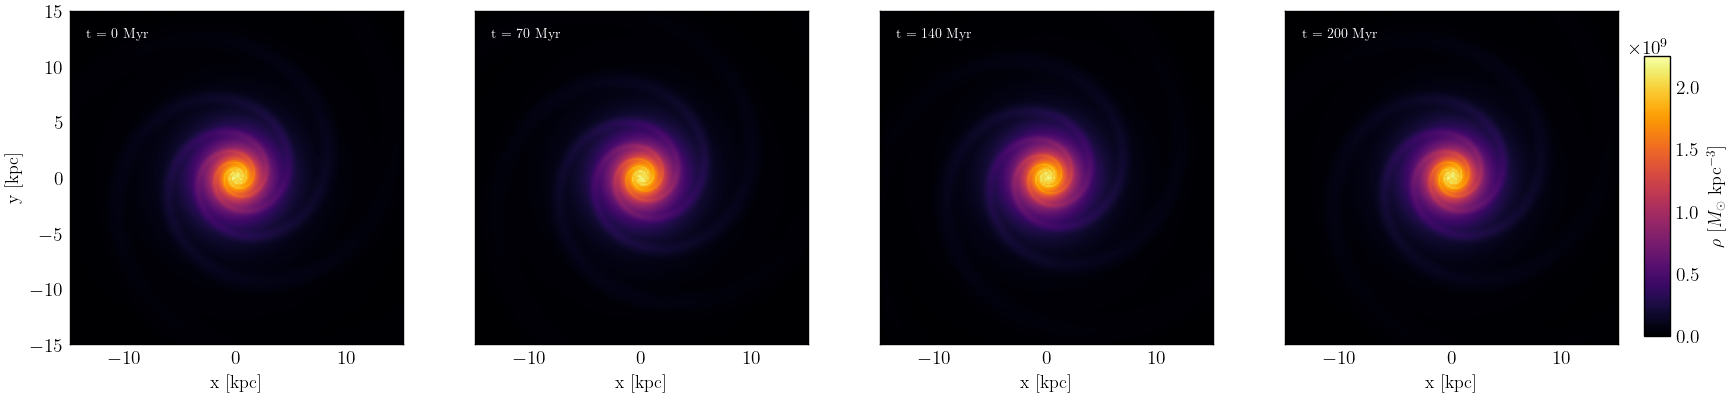

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharex=True, sharey=True)

vmax = max(d.max() for d in dens_snapshots)
vmin = 0.0

for ax, dens, t in zip(axes, dens_snapshots, times):
    im = ax.imshow(dens, origin='lower', extent=[-15, 15, -15, 15], cmap='inferno', vmin=vmin, vmax=vmax)
    ax.set_xlabel('x [kpc]')
    ax.text(0.05, 0.92, f't = {float(t):.0f} Myr', transform=ax.transAxes, color='white', fontsize=10)

axes[0].set_ylabel('y [kpc]')
fig.subplots_adjust(right=0.9)

# move cbar to right
cax = fig.add_axes([0.99, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cax, label=r'$\rho$ [$M_\odot$ kpc$^{-3}$]')
plt.show()

### spiral-only acceleration magnitude

same idea but just the perturbation (no disk), so the arms are obvious in
the force field too.

In [28]:
acc_fn = jax.jit(jax.vmap(spiral.acceleration, in_axes=(0, None)))

times_acc = jnp.array([0.0, 100.0, 200.0])
acc_snapshots = [np.linalg.norm(np.array(acc_fn(xyz_grid, float(t))), axis=-1).reshape(X.shape) for t in times_acc]

/opt/anaconda3/envs/streamsculptor_env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


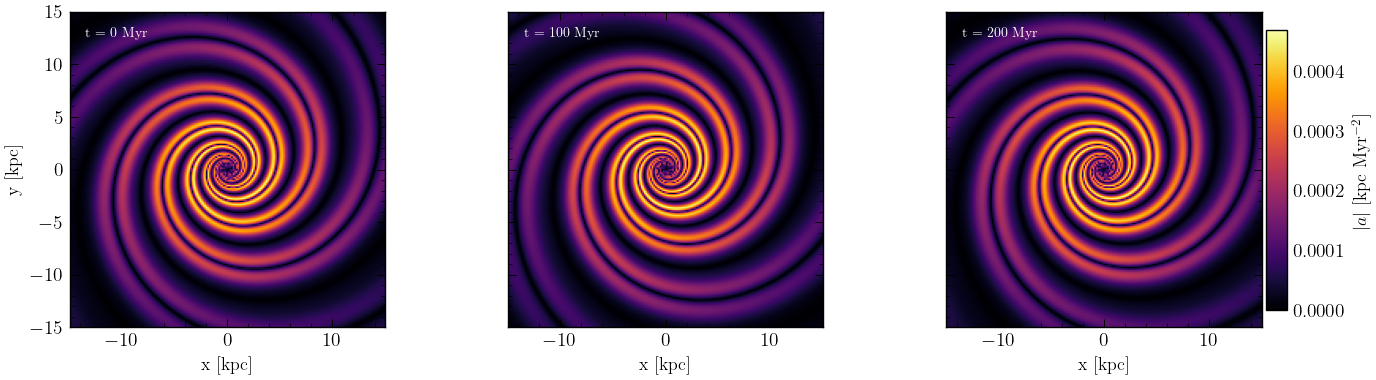

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)

vmax = max(a.max() for a in acc_snapshots)

for ax, acc, t in zip(axes, acc_snapshots, times_acc):
    im = ax.imshow(acc, origin='lower', extent=[-15, 15, -15, 15], cmap='inferno', vmin=0.0, vmax=vmax)
    ax.set_xlabel('x [kpc]')
    ax.text(0.05, 0.92, f't = {float(t):.0f} Myr', transform=ax.transAxes, color='white', fontsize=10)

axes[0].set_ylabel('y [kpc]')
fig.subplots_adjust(right=0.9)
cax = fig.add_axes([0.95, 0.2, 0.015, 0.7])
fig.colorbar(im, cax=cax, label=r'$|a|$ [kpc Myr$^{-2}$]')
plt.show()